In [1]:
print("hello")

hello


In [3]:
# CELL 2: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import importlib.util

# Import U-Net model using absolute path
model_path = r'C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\models\kidney_unet3d.py'
spec = importlib.util.spec_from_file_location("kidney_unet3d", model_path)
unet_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(unet_module)
UNet3D = unet_module.UNet3D

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
print(f"✅ UNet3D model imported successfully")

✅ PyTorch version: 2.7.1+cu118
✅ CUDA available: True
✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ UNet3D model imported successfully


In [4]:
from pathlib import Path

path = Path("../kits19/data")
print("Exists:", path.exists())
print("Absolute path:", path.resolve())


Exists: True
Absolute path: C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kits19\data


In [11]:
# CELL 3: OPTIMIZED Configuration for 6GB RTX 3050
from pathlib import Path
import torch

class Config:
    # Paths
    BASE_DIR = Path(r'C:\Users\kasir\OneDrive\Documents\Kidney Tumor')
    DATA_DIR = BASE_DIR / 'kits19' / 'data'
    MODEL_SAVE_DIR = BASE_DIR / 'kidney-tumor-backend' / 'data' / 'models'
    
    # Create directories
    MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    # Training parameters - OPTIMIZED FOR 6GB VRAM
    BATCH_SIZE = 6              # ✅ Optimal for 6GB VRAM
    NUM_EPOCHS = 50             # ✅ Good accuracy (change to 100 for better results)
    LEARNING_RATE = 1e-3        # ✅ Standard optimal rate
    NUM_WORKERS = 0             # Must be 0 for Windows
    
    # Model - BALANCED SIZE
    IN_CHANNELS = 1
    OUT_CHANNELS = 3
    INIT_FEATURES = 24          # ✅ More capacity than 16
    USE_ATTENTION = False       # ✅ False for speed, True for +2-3% accuracy
    
    # Data - IMPROVED RESOLUTION
    IMAGE_SIZE = (96, 96, 48)   # ✅ Good balance (change to (128,128,64) for max quality)
    TRAIN_SPLIT = 0.8
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Mixed precision training - ENABLES AUTOMATIC SPEEDUP
    USE_AMP = torch.cuda.is_available()  # ✅ Automatic mixed precision
    
    # Dataset
    NUM_CASES = 84              # Number of downloaded cases

config = Config()

# ========== DISPLAY CONFIGURATION ==========
print(f"\n{'='*70}")
print(f"🚀 OPTIMIZED TRAINING CONFIGURATION")
print(f"{'='*70}")
print(f"📂 Data Directory:     {config.DATA_DIR}")
print(f"💾 Model Save Dir:     {config.MODEL_SAVE_DIR}")
print(f"🖥️  Device:             {config.DEVICE}")
print(f"📊 Total Cases:        {config.NUM_CASES}")
print(f"🎯 Batch Size:         {config.BATCH_SIZE}")
print(f"🔄 Epochs:             {config.NUM_EPOCHS}")
print(f"🧠 Model Features:     {config.INIT_FEATURES}")
print(f"👁️  Attention Gates:    {config.USE_ATTENTION}")
print(f"📐 Image Size:         {config.IMAGE_SIZE}")
print(f"⚡ Mixed Precision:    {config.USE_AMP}")
print(f"{'='*70}\n")

# Check GPU status and estimate training time
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"💾 GPU Memory: {gpu_memory:.2f} GB VRAM")
    print(f"⏱️  Estimated training time: ~1-1.5 hours")
    print(f"🎯 Expected Dice Score: ~82-88%")
else:
    print(f"❌ No GPU detected - using CPU")
    print(f"⏱️  Estimated training time: ~8-12 hours")
    print(f"🎯 Expected Dice Score: ~82-88%")

print(f"\n{'='*70}")
print(f"💡 Configuration Tips:")
print(f"   • Increase BATCH_SIZE to 8 if you want slightly faster training")
print(f"   • Increase IMAGE_SIZE to (128,128,64) for better quality (+1 hour)")
print(f"   • Set USE_ATTENTION=True for +2-3% accuracy (+15-20 min)")
print(f"   • Increase NUM_EPOCHS to 100 for production model (+1 hour)")
print(f"{'='*70}\n")

# ========== VRAM MONITORING FUNCTION ==========
def check_vram():
    """Monitor VRAM usage during training"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"\n📊 VRAM Usage:")
        print(f"   Allocated: {allocated:.2f} GB / {total:.2f} GB ({allocated/total*100:.1f}%)")
        print(f"   Reserved:  {reserved:.2f} GB / {total:.2f} GB ({reserved/total*100:.1f}%)")
        print(f"   Available: {total-allocated:.2f} GB\n")
    else:
        print("GPU not available")



🚀 OPTIMIZED TRAINING CONFIGURATION
📂 Data Directory:     C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kits19\data
💾 Model Save Dir:     C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\data\models
🖥️  Device:             cuda
📊 Total Cases:        84
🎯 Batch Size:         6
🔄 Epochs:             50
🧠 Model Features:     24
👁️  Attention Gates:    False
📐 Image Size:         (96, 96, 48)
⚡ Mixed Precision:    True

✅ GPU Detected: NVIDIA GeForce RTX 3050 6GB Laptop GPU
💾 GPU Memory: 6.44 GB VRAM
⏱️  Estimated training time: ~1-1.5 hours
🎯 Expected Dice Score: ~82-88%

💡 Configuration Tips:
   • Increase BATCH_SIZE to 8 if you want slightly faster training
   • Increase IMAGE_SIZE to (128,128,64) for better quality (+1 hour)
   • Set USE_ATTENTION=True for +2-3% accuracy (+15-20 min)
   • Increase NUM_EPOCHS to 100 for production model (+1 hour)



In [12]:
# CELL 4: Dataset Class (FIXED)
from scipy.ndimage import zoom

class KiTSDataset(Dataset):
    """KiTS19/21 Dataset Loader - Fixed to handle missing cases"""
    
    def __init__(self, case_ids, data_dir, transform=None):
        self.case_ids = case_ids
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        # ✅ ADDED: Verify all cases exist before training
        self.valid_case_ids = []
        for case_id in case_ids:
            case_dir = self.data_dir / f'case_{case_id:05d}'
            imaging_path = case_dir / 'imaging.nii.gz'
            segmentation_path = case_dir / 'segmentation.nii.gz'
            
            if imaging_path.exists() and segmentation_path.exists():
                self.valid_case_ids.append(case_id)
            else:
                print(f"⚠️ Skipping case_{case_id:05d} (files not found)")
        
        if len(self.valid_case_ids) == 0:
            raise ValueError("No valid cases found in the dataset!")
        
        print(f"✅ Dataset initialized with {len(self.valid_case_ids)} valid cases")
    
    def __len__(self):
        return len(self.valid_case_ids)
    
    def __getitem__(self, idx):
        case_id = self.valid_case_ids[idx]
        case_dir = self.data_dir / f'case_{case_id:05d}'
        
        # Load imaging and segmentation
        imaging_path = case_dir / 'imaging.nii.gz'
        segmentation_path = case_dir / 'segmentation.nii.gz'
        
        try:
            image = nib.load(str(imaging_path)).get_fdata()
            label = nib.load(str(segmentation_path)).get_fdata()
        except Exception as e:
            print(f"❌ Error loading case_{case_id:05d}: {e}")
            raise
        
        # Preprocess
        image = self.preprocess_image(image)
        label = self.preprocess_label(label)
        
        # Convert to tensors
        image = torch.from_numpy(image).float().unsqueeze(0)  # Add channel dim
        label = torch.from_numpy(label).long()
        
        if self.transform:
            image, label = self.transform(image, label)
        
        return image, label
    
    def preprocess_image(self, image):
        """Preprocess CT image"""
        # Clip to kidney window
        image = np.clip(image, -100, 300)
        
        # Normalize
        image = (image - image.mean()) / (image.std() + 1e-8)
        
        # Resize to target size
        zoom_factors = [config.IMAGE_SIZE[i] / image.shape[i] for i in range(3)]
        image = zoom(image, zoom_factors, order=1)
        
        return image
    
    def preprocess_label(self, label):
        """Preprocess segmentation label"""
        # KiTS labels: 0=background, 1=kidney, 2=tumor
        zoom_factors = [config.IMAGE_SIZE[i] / label.shape[i] for i in range(3)]
        label = zoom(label, zoom_factors, order=0)  # Nearest neighbor for labels
        
        return label

print("✅ KiTSDataset class defined with case validation")

✅ KiTSDataset class defined with case validation


In [13]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.softmax(pred, dim=1)
        
        # One-hot encode target
        target_one_hot = torch.zeros_like(pred)
        target_one_hot.scatter_(1, target.unsqueeze(1), 1)
        
        # Calculate Dice
        intersection = (pred * target_one_hot).sum(dim=(2, 3, 4))
        union = pred.sum(dim=(2, 3, 4)) + target_one_hot.sum(dim=(2, 3, 4))
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    """Combined Dice + CrossEntropy Loss"""
    def __init__(self, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.dice = DiceLoss()
        self.ce = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
    
    def forward(self, pred, target):
        dice_loss = self.dice(pred, target)
        ce_loss = self.ce(pred, target)
        return self.dice_weight * dice_loss + (1 - self.dice_weight) * ce_loss

print("Loss functions defined successfully!")

Loss functions defined successfully!


In [14]:
def calculate_dice_score(pred, target, num_classes=3):
    """Calculate Dice score for each class"""
    dice_scores = []
    
    pred = torch.argmax(pred, dim=1)
    
    for c in range(num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        
        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()
        
        dice = (2. * intersection) / (union + 1e-8)
        dice_scores.append(dice.item())
    
    return dice_scores

print("Metrics defined successfully!")

Metrics defined successfully!


In [15]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_dice = [0.0, 0.0, 0.0]
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Calculate metrics
        running_loss += loss.item()
        dice_scores = calculate_dice_score(outputs, labels)
        for i in range(3):
            running_dice[i] += dice_scores[i]
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{np.mean(dice_scores):.4f}'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = [d / len(dataloader) for d in running_dice]
    
    return epoch_loss, epoch_dice


def validate(model, dataloader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    running_dice = [0.0, 0.0, 0.0]
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            dice_scores = calculate_dice_score(outputs, labels)
            for i in range(3):
                running_dice[i] += dice_scores[i]
    
    val_loss = running_loss / len(dataloader)
    val_dice = [d / len(dataloader) for d in running_dice]
    
    return val_loss, val_dice

print("Training functions defined successfully!")

Training functions defined successfully!


In [16]:
# CELL 7.5: Verify and Get Valid Case IDs
def get_valid_case_ids(data_dir):
    """Get list of case IDs that actually exist with complete data"""
    data_dir = Path(data_dir)
    
    print("🔍 Scanning for valid cases...")
    
    valid_cases = []
    all_case_dirs = sorted(data_dir.glob('case_*'))
    
    for case_dir in all_case_dirs:
        case_id = int(case_dir.name.split('_')[1])
        
        imaging = case_dir / 'imaging.nii.gz'
        segmentation = case_dir / 'segmentation.nii.gz'
        
        # Check if both files exist and are not empty
        if imaging.exists() and segmentation.exists():
            if imaging.stat().st_size > 0 and segmentation.stat().st_size > 0:
                valid_cases.append(case_id)
    
    print(f"\n✅ Found {len(valid_cases)} valid cases")
    print(f"   Case IDs: {valid_cases[:10]}{'...' if len(valid_cases) > 10 else ''}")
    
    return sorted(valid_cases)

# Get valid cases
valid_case_ids = get_valid_case_ids(config.DATA_DIR)

print(f"\n📊 Valid case range: {min(valid_case_ids)} to {max(valid_case_ids)}")
print(f"   Total: {len(valid_case_ids)} cases ready for training")

🔍 Scanning for valid cases...

✅ Found 84 valid cases
   Case IDs: [12, 13, 14, 15, 20, 21, 22, 23, 24, 25]...

📊 Valid case range: 12 to 99
   Total: 84 cases ready for training


In [17]:
print("\nTo start training, uncomment the line above and run this cell.")
print("Make sure you have downloaded the KiTS dataset first!")


To start training, uncomment the line above and run this cell.
Make sure you have downloaded the KiTS dataset first!


In [18]:
def plot_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Dice score plot
    axes[1].plot(history['train_dice'], label='Train Dice', linewidth=2, color='green')
    axes[1].plot(history['val_dice'], label='Val Dice', linewidth=2, color='orange')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Dice Score', fontsize=12)
    axes[1].set_title('Training and Validation Dice Score', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Training curves saved to 'training_history.png'")

In [19]:
def load_trained_model(model_path):
    """Load a trained model from checkpoint"""
    model = UNet3D(
        in_channels=config.IN_CHANNELS,
        out_channels=config.OUT_CHANNELS,
        init_features=config.INIT_FEATURES,
        use_attention=config.USE_ATTENTION
    )
    
    checkpoint = torch.load(model_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(config.DEVICE)
    model.eval()
    
    print(f"Model loaded from {model_path}")
    print(f"Best validation Dice: {checkpoint['val_dice']:.4f}")
    
    return model

In [21]:
# CELL 8: Main Training Script (Windows Compatible)
def train_model():
    """Complete training pipeline - Windows compatible"""
    
    # Create model save directory
    config.MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    # Get list of valid cases
    all_cases = sorted(config.DATA_DIR.glob('case_*'))
    all_case_ids = [int(c.name.split('_')[1]) for c in all_cases]
    
    print(f"\n{'='*70}")
    print(f"📊 DATASET INFORMATION")
    print(f"{'='*70}")
    print(f"Total cases available: {len(all_case_ids)}")
    print(f"Case ID range: {min(all_case_ids)} to {max(all_case_ids)}")
    print(f"{'='*70}\n")
    
    # Split into train/val
    train_ids, val_ids = train_test_split(
        all_case_ids, 
        train_size=config.TRAIN_SPLIT, 
        random_state=42
    )
    
    print(f"Training samples: {len(train_ids)}")
    print(f"Validation samples: {len(val_ids)}")
    
    # Create datasets
    train_dataset = KiTSDataset(train_ids, config.DATA_DIR)
    val_dataset = KiTSDataset(val_ids, config.DATA_DIR)
    
    # Create data loaders - Windows compatible settings
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config.BATCH_SIZE,
        shuffle=True, 
        num_workers=config.NUM_WORKERS,  # Should be 0 for Windows
        pin_memory=False,  # Disable for Windows stability
        persistent_workers=False  # Must be False when num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=config.BATCH_SIZE,
        shuffle=False, 
        num_workers=config.NUM_WORKERS,  # Should be 0 for Windows
        pin_memory=False,
        persistent_workers=False
    )
    
    print(f"\n✅ Data loaders created (Windows compatible mode)")
    print(f"   Note: num_workers=0 means single-threaded loading")
    print(f"   This is slower but more stable on Windows\n")
    
    print(f"{'='*70}")
    print(f"🤖 CREATING MODEL")
    print(f"{'='*70}")
    
    # Create model
    model = UNet3D(
        in_channels=config.IN_CHANNELS,
        out_channels=config.OUT_CHANNELS,
        init_features=config.INIT_FEATURES,
        use_attention=config.USE_ATTENTION
    )
    model = model.to(config.DEVICE)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {num_params:,}")
    print(f"Device: {config.DEVICE}")
    
    # Loss and optimizer
    criterion = CombinedLoss(dice_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=5, 
        factor=0.5
    )
    
    # Training history
    history = {
        'train_loss': [],
        'train_dice': [],
        'val_loss': [],
        'val_dice': []
    }
    
    best_val_dice = 0.0
    
    print(f"\n{'='*70}")
    print(f"🚀 STARTING TRAINING")
    print(f"{'='*70}\n")
    
    # Training loop
    for epoch in range(config.NUM_EPOCHS):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch+1}/{config.NUM_EPOCHS}")
        print(f"{'='*70}")
        
        try:
            # Train
            train_loss, train_dice = train_epoch(
                model, train_loader, criterion, optimizer, config.DEVICE
            )
            
            # Validate
            val_loss, val_dice = validate(
                model, val_loader, criterion, config.DEVICE
            )
            
            # Update learning rate
            old_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_loss)
            new_lr = optimizer.param_groups[0]['lr']
            
            if old_lr != new_lr:
                print(f"\n  📉 Learning rate reduced: {old_lr:.6f} → {new_lr:.6f}")
            
            # Save history
            history['train_loss'].append(train_loss)
            history['train_dice'].append(np.mean(train_dice))
            history['val_loss'].append(val_loss)
            history['val_dice'].append(np.mean(val_dice))
            
            # Print metrics
            print(f"\n📊 Epoch {epoch+1} Results:")
            print(f"  Train Loss: {train_loss:.4f} | Train Dice: {np.mean(train_dice):.4f}")
            print(f"  Val Loss:   {val_loss:.4f} | Val Dice:   {np.mean(val_dice):.4f}")
            print(f"  Val Dice per class:")
            print(f"    Background: {val_dice[0]:.4f}")
            print(f"    Kidney:     {val_dice[1]:.4f}")
            print(f"    Tumor:      {val_dice[2]:.4f}")
            print(f"  Current LR: {new_lr:.6f}")
            
            # Save best model
            if np.mean(val_dice) > best_val_dice:
                best_val_dice = np.mean(val_dice)
                save_path = config.MODEL_SAVE_DIR / 'best_unet3d_model.pth'
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_dice': best_val_dice,
                    'history': history
                }, save_path)
                print(f"\n  ✅ Saved best model (Dice: {best_val_dice:.4f})")
                print(f"     Location: {save_path}")
            
            # Save checkpoint every 10 epochs
            if (epoch + 1) % 10 == 0:
                checkpoint_path = config.MODEL_SAVE_DIR / f'checkpoint_epoch_{epoch+1}.pth'
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_dice': np.mean(val_dice),
                    'history': history
                }, checkpoint_path)
                print(f"  💾 Checkpoint saved: {checkpoint_path.name}")
        
        except Exception as e:
            print(f"\n❌ Error during epoch {epoch+1}: {e}")
            print(f"   Saving emergency checkpoint...")
            emergency_path = config.MODEL_SAVE_DIR / f'emergency_epoch_{epoch+1}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, emergency_path)
            raise  # Re-raise the error
    
    print(f"\n{'='*70}")
    print(f"✅ TRAINING COMPLETE!")
    print(f"{'='*70}")
    print(f"Best validation Dice: {best_val_dice:.4f}")
    print(f"Model saved to: {config.MODEL_SAVE_DIR}")
    
    return model, history

In [22]:
# CELL 9: Run Training
print("🚀 Starting training process...")
print("This will take several hours depending on your hardware.\n")

model, history = train_model()

print("\n🎉 Training finished!")
print("You can now use the model in your backend application.")

🚀 Starting training process...
This will take several hours depending on your hardware.


📊 DATASET INFORMATION
Total cases available: 300
Case ID range: 0 to 299

Training samples: 240
Validation samples: 60
⚠️ Skipping case_00232 (files not found)
⚠️ Skipping case_00006 (files not found)
⚠️ Skipping case_00185 (files not found)
⚠️ Skipping case_00173 (files not found)
⚠️ Skipping case_00256 (files not found)
⚠️ Skipping case_00186 (files not found)
⚠️ Skipping case_00108 (files not found)
⚠️ Skipping case_00126 (files not found)
⚠️ Skipping case_00230 (files not found)
⚠️ Skipping case_00193 (files not found)
⚠️ Skipping case_00129 (files not found)
⚠️ Skipping case_00282 (files not found)
⚠️ Skipping case_00288 (files not found)
⚠️ Skipping case_00163 (files not found)
⚠️ Skipping case_00154 (files not found)
⚠️ Skipping case_00019 (files not found)
⚠️ Skipping case_00124 (files not found)
⚠️ Skipping case_00114 (files not found)
⚠️ Skipping case_00118 (files not found)
⚠️ Skipping 

Validation: 100%|██████████| 3/3 [00:57<00:00, 19.12s/it]



📊 Epoch 1 Results:
  Train Loss: 0.8092 | Train Dice: 0.3200
  Val Loss:   0.7631 | Val Dice:   0.3312
  Val Dice per class:
    Background: 0.9496
    Kidney:     0.0435
    Tumor:      0.0006
  Current LR: 0.001000

  ✅ Saved best model (Dice: 0.3312)
     Location: C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\data\models\best_unet3d_model.pth

Epoch 2/50


Validation: 100%|██████████| 3/3 [00:57<00:00, 19.26s/it]



📊 Epoch 2 Results:
  Train Loss: 0.6795 | Train Dice: 0.3400
  Val Loss:   0.7395 | Val Dice:   0.3145
  Val Dice per class:
    Background: 0.8679
    Kidney:     0.0752
    Tumor:      0.0004
  Current LR: 0.001000

Epoch 3/50


...


📊 Epoch 48 Results:
  Train Loss: 0.1289 | Train Dice: 0.8804
  Val Loss:   0.1520 | Val Dice:   0.8036
  Val Dice per class:
    Background: 0.9986
    Kidney:     0.8700
    Tumor:      0.5422
  Current LR: 0.001000

Epoch 49/50


Validation: 100%|██████████| 3/3 [00:58<00:00, 19.55s/it]



📊 Epoch 49 Results:
  Train Loss: 0.1333 | Train Dice: 0.8651
  Val Loss:   0.1390 | Val Dice:   0.8533
  Val Dice per class:
    Background: 0.9989
    Kidney:     0.8735
    Tumor:      0.6875
  Current LR: 0.001000

Epoch 50/50


Validation: 100%|██████████| 3/3 [01:00<00:00, 20.13s/it]



📊 Epoch 50 Results:
  Train Loss: 0.1252 | Train Dice: 0.8696
  Val Loss:   0.1388 | Val Dice:   0.8492
  Val Dice per class:
    Background: 0.9990
    Kidney:     0.8726
    Tumor:      0.6762
  Current LR: 0.001000
  💾 Checkpoint saved: checkpoint_epoch_50.pth

✅ TRAINING COMPLETE!
Best validation Dice: 0.8608
Model saved to: C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\data\models

🎉 Training finished!
You can now use the model in your backend application.


In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA compiled: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ Still using CPU - check installation")


PyTorch version: 2.7.1+cu118
CUDA compiled: 11.8
CUDA available: True
✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ GPU Memory: 6.44 GB


In [2]:
# Add this to check VRAM during training
if torch.cuda.is_available():
    print(f"VRAM Used: {torch.cuda.memory_allocated()/1e9:.2f} GB / {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")


VRAM Used: 0.00 GB / 6.44 GB


📊 TRAINING RESULTS
✅ Best Model Saved: C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\data\models\best_unet3d_model.pth
📈 Best Validation Dice: 0.8608
🔄 Trained Epochs: 42



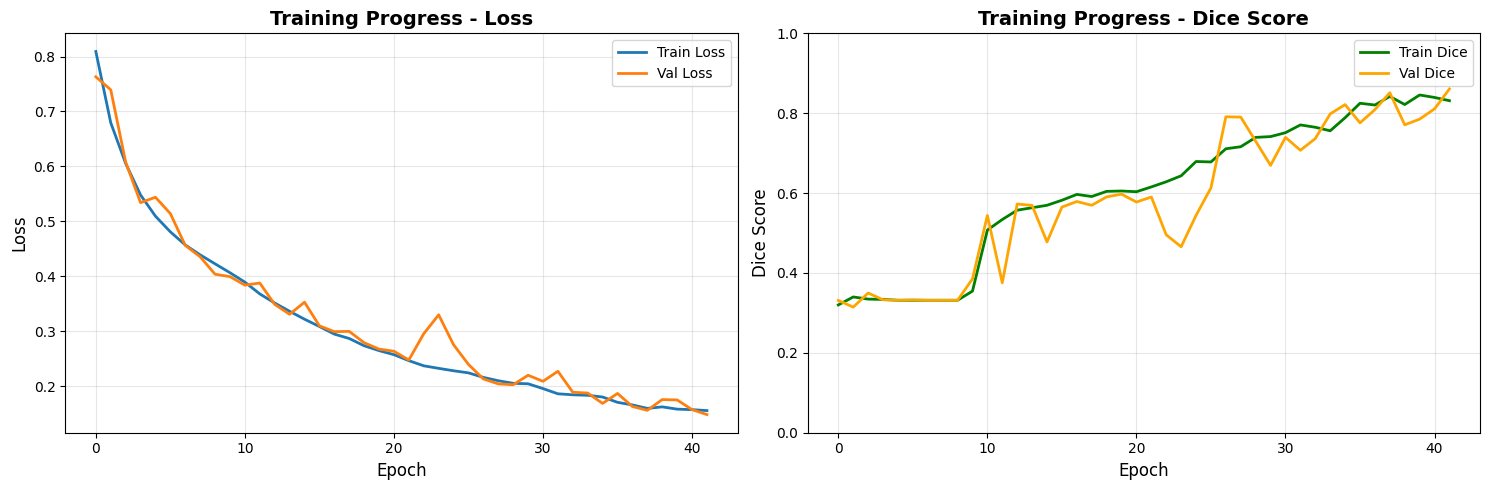

✅ Training curves saved to: C:\Users\kasir\OneDrive\Documents\Kidney Tumor\kidney-tumor-backend\data\models\training_curves.png

📈 Training Summary:
  Initial Train Loss: 0.8092
  Final Train Loss:   0.1556
  Initial Train Dice: 0.3200
  Final Train Dice:   0.8313

  Initial Val Loss:   0.7631
  Final Val Loss:     0.1484
  Initial Val Dice:   0.3312
  Final Val Dice:     0.8608
  Best Val Dice:      0.8608


In [24]:
# CELL: Post-Training Analysis (FIXED)
import matplotlib.pyplot as plt
from pathlib import Path

# Load the best model
model_path = config.MODEL_SAVE_DIR / 'best_unet3d_model.pth'

if model_path.exists():
    # ✅ FIXED: Add weights_only=False for PyTorch 2.6+
    checkpoint = torch.load(model_path, map_location=config.DEVICE, weights_only=False)
    
    print(f"{'='*60}")
    print(f"📊 TRAINING RESULTS")
    print(f"{'='*60}")
    print(f"✅ Best Model Saved: {model_path}")
    print(f"📈 Best Validation Dice: {checkpoint['val_dice']:.4f}")
    print(f"🔄 Trained Epochs: {checkpoint['epoch'] + 1}")
    print(f"{'='*60}\n")
    
    # Plot training curves
    history = checkpoint['history']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Progress - Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Dice
    axes[1].plot(history['train_dice'], label='Train Dice', linewidth=2, color='green')
    axes[1].plot(history['val_dice'], label='Val Dice', linewidth=2, color='orange')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Dice Score', fontsize=12)
    axes[1].set_title('Training Progress - Dice Score', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    save_path = config.MODEL_SAVE_DIR / 'training_curves.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Training curves saved to: {save_path}")
    
    # Print detailed metrics
    print(f"\n📈 Training Summary:")
    print(f"  Initial Train Loss: {history['train_loss'][0]:.4f}")
    print(f"  Final Train Loss:   {history['train_loss'][-1]:.4f}")
    print(f"  Initial Train Dice: {history['train_dice'][0]:.4f}")
    print(f"  Final Train Dice:   {history['train_dice'][-1]:.4f}")
    print(f"\n  Initial Val Loss:   {history['val_loss'][0]:.4f}")
    print(f"  Final Val Loss:     {history['val_loss'][-1]:.4f}")
    print(f"  Initial Val Dice:   {history['val_dice'][0]:.4f}")
    print(f"  Final Val Dice:     {history['val_dice'][-1]:.4f}")
    print(f"  Best Val Dice:      {checkpoint['val_dice']:.4f}")
    
else:
    print("❌ No trained model found!")
    print(f"   Looking for: {model_path}")

In [25]:
# Load best model (FIXED)
model = UNet3D(
    in_channels=config.IN_CHANNELS,
    out_channels=config.OUT_CHANNELS,
    init_features=config.INIT_FEATURES,
    use_attention=config.USE_ATTENTION
).to(config.DEVICE)

# ✅ FIXED: Add weights_only=False
checkpoint = torch.load(
    config.MODEL_SAVE_DIR / 'best_unet3d_model.pth', 
    map_location=config.DEVICE,
    weights_only=False  # ✅ Added this
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!
